In [ ]:
"""
Random Forest

Dataset Description:

Use the Glass dataset and apply the Random forest model.

1. Exploratory Data Analysis (EDA):

Perform exploratory data analysis to understand the structure of the dataset.
Check for missing values, outliers, inconsistencies in the data.

2: Data Visualization:

Create visualizations such as histograms, box plots, or pair plots to visualize the distributions and relationships between features.
Analyze any patterns or correlations observed in the data.

3: Data Preprocessing

1. Check for missing values in the dataset and decide on a strategy for handling them.Implement the chosen strategy (e.g., imputation or removal) and explain your reasoning.
2. If there are categorical variables, apply encoding techniques like one-hot encoding to convert them into numerical format.
3. Apply feature scaling techniques such as standardization or normalization to ensure that all features are on a similar scale. Handling the imbalance data.

4: Random Forest Model Implementation
1. Divide the data into train and test split.
2. Implement a Random Forest classifier using Python and a machine learning library like scikit-learn.
3. Train the model on the train dataset. Evaluate the performance on test data using metrics like accuracy, precision, recall, and F1-score.

5: Bagging and Boosting Methods
Apply the Bagging and Boosting methods and compare the results.


Additional Notes:
1. Explain Bagging and Boosting methods. How is it different from each other.
2. Explain how to handle imbalance in the data.

"""


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [3]:
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Load data
df = pd.read_excel('Assi_12_glass.xlsx', sheet_name='glass')

In [6]:
#TASK 1: EXPLORATORY DATA ANALYSIS




In [7]:
print("\nDataset Shape:", df.shape)


Dataset Shape: (214, 10)


In [8]:
print("\nColumn Names:")
print(list(df.columns))


Column Names:
['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type']


In [9]:
print("\nFirst 5 rows:")
print(df.head())


First 5 rows:
        RI     Na    Mg    Al     Si     K    Ca   Ba   Fe  Type
0  1.52101  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.0     1
1  1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.0     1
2  1.51618  13.53  3.55  1.54  72.99  0.39  7.78  0.0  0.0     1
3  1.51766  13.21  3.69  1.29  72.61  0.57  8.22  0.0  0.0     1
4  1.51742  13.27  3.62  1.24  73.08  0.55  8.07  0.0  0.0     1


In [10]:
print("\nData Types:")
print(df.dtypes)


Data Types:
RI      float64
Na      float64
Mg      float64
Al      float64
Si      float64
K       float64
Ca      float64
Ba      float64
Fe      float64
Type      int64
dtype: object


In [11]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64


In [12]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
               RI          Na          Mg          Al          Si           K  \
count  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000   
mean     1.518365   13.407850    2.684533    1.444907   72.650935    0.497056   
std      0.003037    0.816604    1.442408    0.499270    0.774546    0.652192   
min      1.511150   10.730000    0.000000    0.290000   69.810000    0.000000   
25%      1.516522   12.907500    2.115000    1.190000   72.280000    0.122500   
50%      1.517680   13.300000    3.480000    1.360000   72.790000    0.555000   
75%      1.519157   13.825000    3.600000    1.630000   73.087500    0.610000   
max      1.533930   17.380000    4.490000    3.500000   75.410000    6.210000   

               Ca          Ba          Fe        Type  
count  214.000000  214.000000  214.000000  214.000000  
mean     8.956963    0.175047    0.057009    2.780374  
std      1.423153    0.497219    0.097439    2.103739  
min      5.430000    0.0

In [13]:
# Check class distribution

In [14]:
print("\nClass Distribution (Type of Glass):")
class_counts = df['Type'].value_counts().sort_index()
glass_types = {
    1: 'building_windows_float_processed',
    2: 'building_windows_non_float_processed',
    3: 'vehicle_windows_float_processed',
    4: 'vehicle_windows_non_float_processed',
    5: 'containers',
    6: 'tableware',
    7: 'headlamps'
}
for glass_type, count in class_counts.items():
    print(f"Type {glass_type} ({glass_types.get(glass_type, 'Unknown')}): {count} samples")



Class Distribution (Type of Glass):
Type 1 (building_windows_float_processed): 70 samples
Type 2 (building_windows_non_float_processed): 76 samples
Type 3 (vehicle_windows_float_processed): 17 samples
Type 5 (containers): 13 samples
Type 6 (tableware): 9 samples
Type 7 (headlamps): 29 samples


In [15]:
# Check for outliers using IQR
print("\nOutlier Detection (IQR method):")
for col in df.columns[:-1]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers")


Outlier Detection (IQR method):
RI: 17 outliers
Na: 7 outliers
Mg: 0 outliers
Al: 18 outliers
Si: 12 outliers
K: 7 outliers
Ca: 26 outliers
Ba: 38 outliers
Fe: 12 outliers


In [16]:
# TASK 2: DATA VISUALIZATION



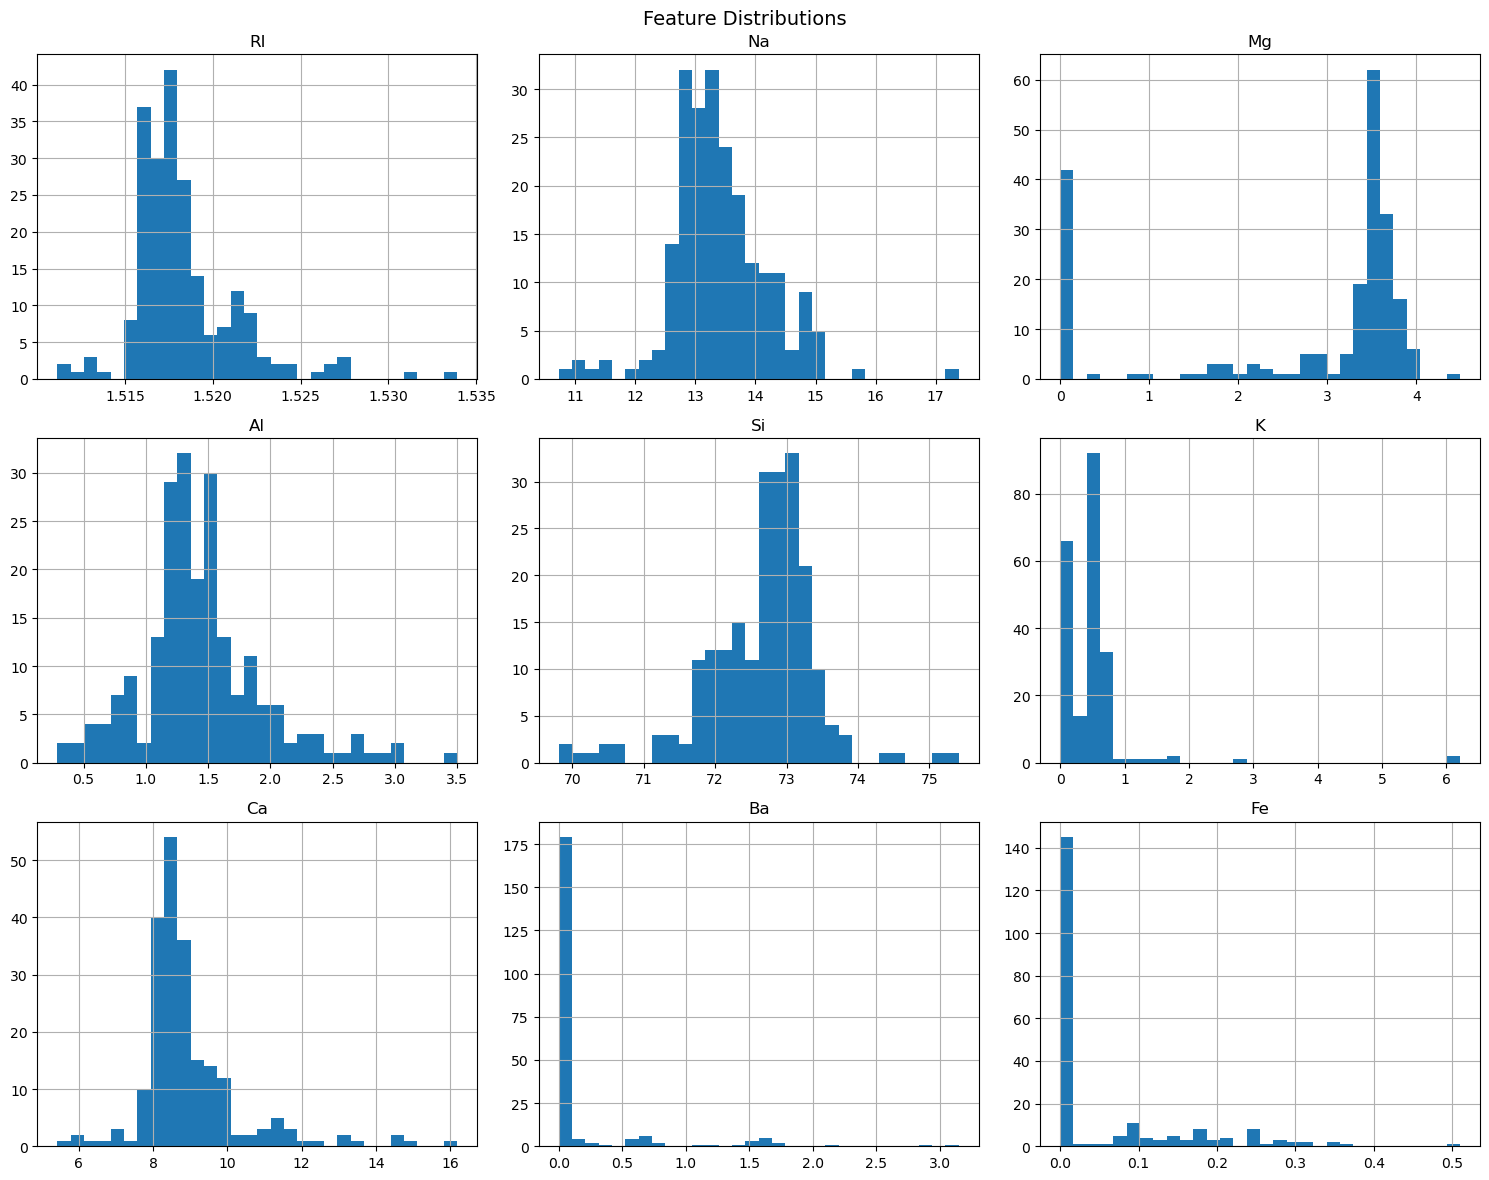

In [17]:
# Histograms of all features
df.iloc[:, :-1].hist(figsize=(15, 12), bins=30)
plt.suptitle("Feature Distributions", fontsize=14)
plt.tight_layout()
plt.savefig('glass_histograms.png')
plt.show()

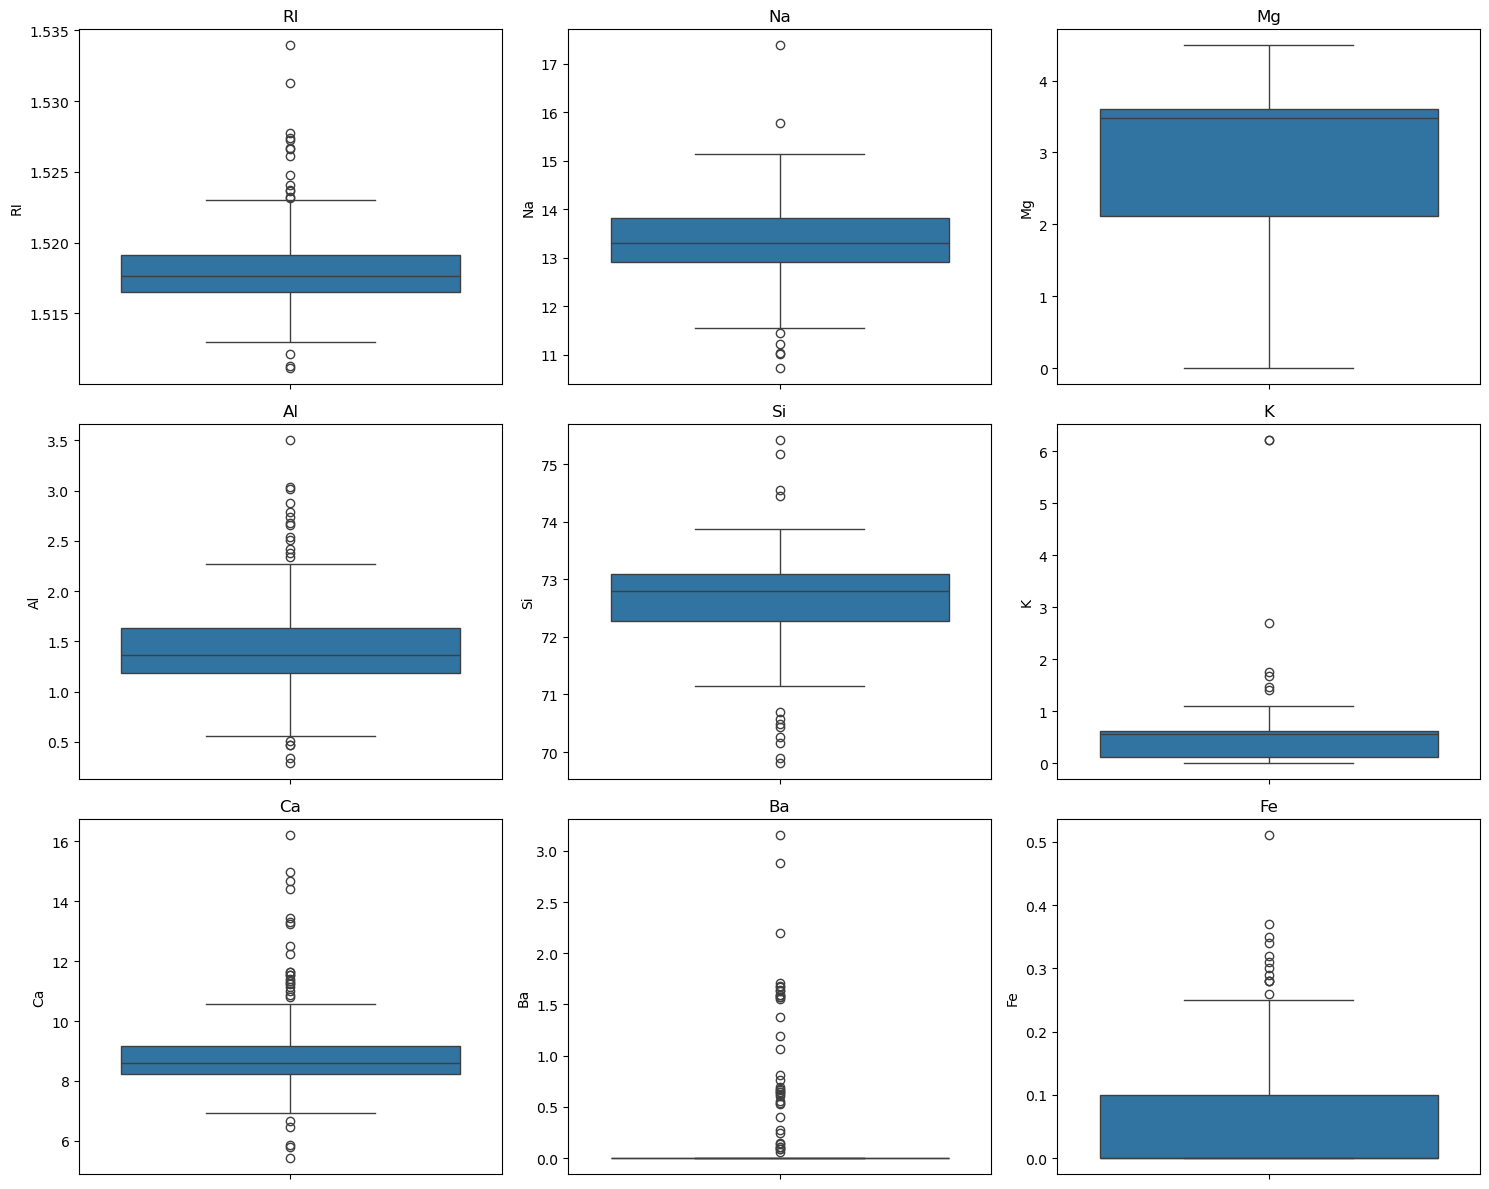

In [18]:
# Box plots
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()
for i, col in enumerate(df.columns[:-1]):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.savefig('glass_boxplots.png')
plt.show()

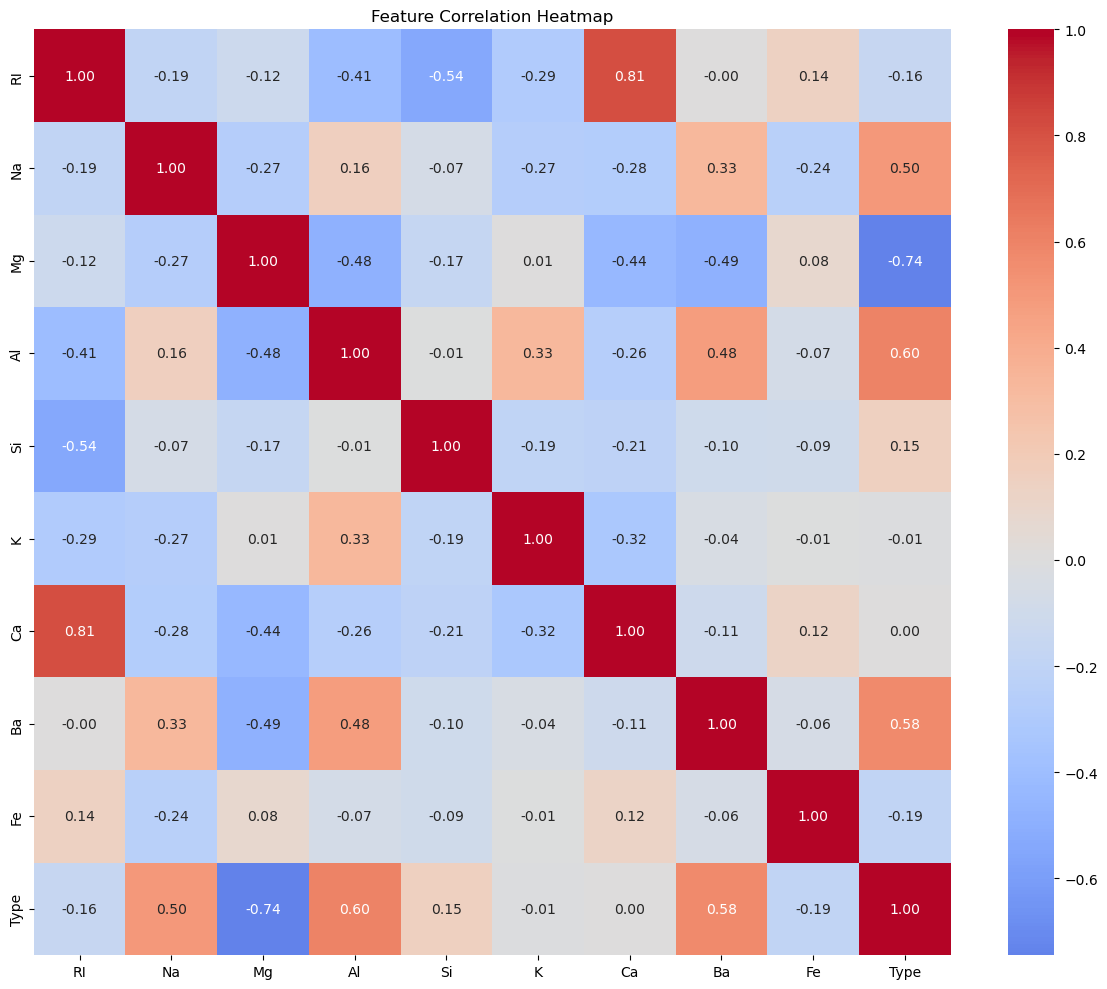


Correlation with Target (Type):
Type    1.000000
Al      0.598829
Ba      0.575161
Na      0.502898
Si      0.151565
Ca      0.000952
K      -0.010054
RI     -0.164237
Fe     -0.188278
Mg     -0.744993
Name: Type, dtype: float64


In [19]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
correlation = df.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig('glass_correlation.png')
plt.show()

print("\nCorrelation with Target (Type):")
corr_with_target = correlation['Type'].sort_values(ascending=False)
print(corr_with_target)

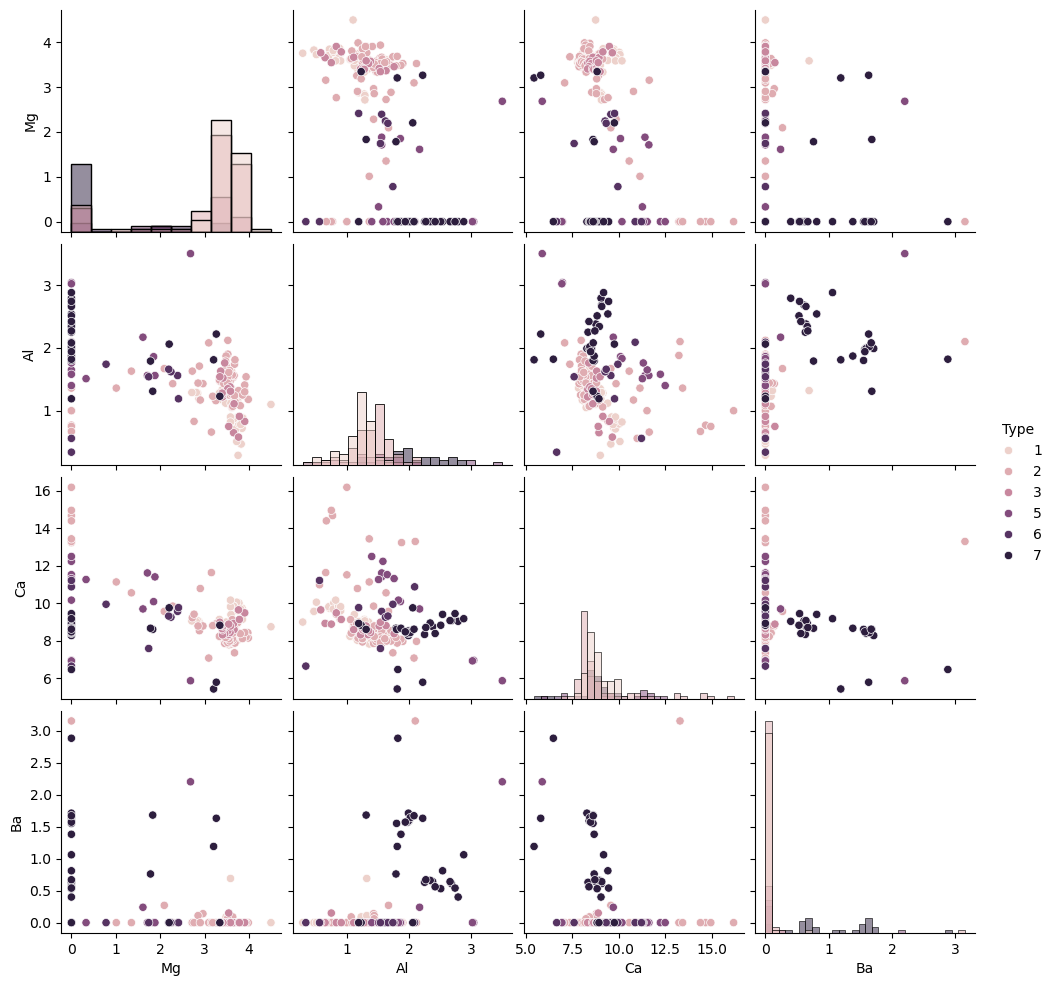

In [20]:
# Pair plot for selected features
selected_features = ['Mg', 'Al', 'Ca', 'Ba', 'Type']
sns.pairplot(df[selected_features], hue='Type', diag_kind='hist')
plt.savefig('glass_pairplot.png')
plt.show()

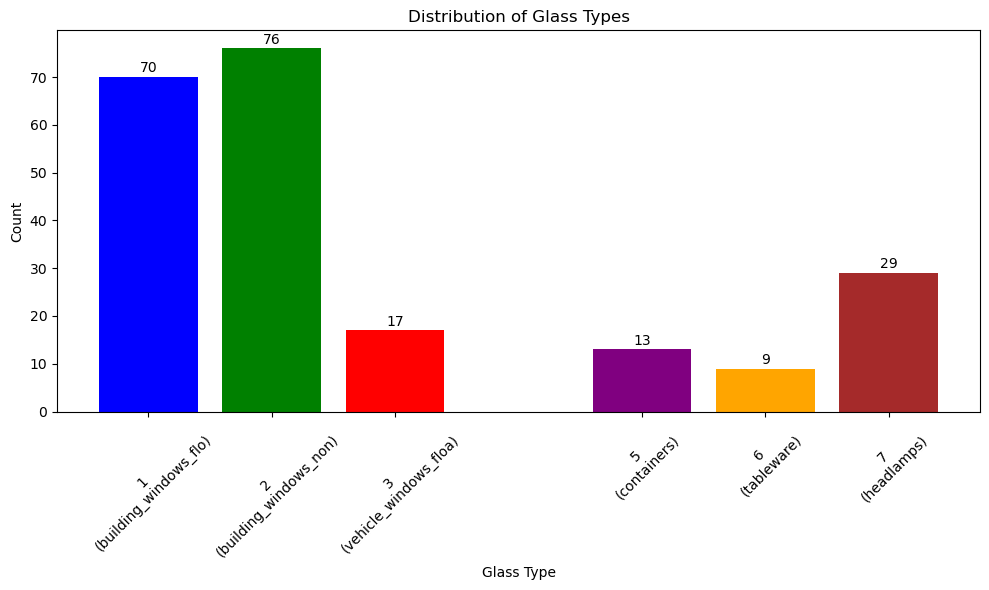

In [21]:
# Class distribution bar plot
plt.figure(figsize=(10, 6))
colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown', 'pink']
bars = plt.bar(class_counts.index, class_counts.values, color=colors[:len(class_counts)])
plt.xlabel('Glass Type')
plt.ylabel('Count')
plt.title('Distribution of Glass Types')
for bar, count in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(count), ha='center')
plt.xticks(class_counts.index, [f"{t}\n({glass_types.get(t, '')[:20]})" for t in class_counts.index], rotation=45)
plt.tight_layout()
plt.savefig('glass_class_distribution.png')
plt.show()

In [22]:
# TASK 3: DATA PREPROCESSING




In [23]:
# 3.1 Handle missing values
print("\n3.1 Handling Missing Values:")
print(f"Missing values before: {df.isnull().sum().sum()}")
# No missing values in this dataset
df_clean = df.copy()
print("No missing values found. Dataset is clean.")


3.1 Handling Missing Values:
Missing values before: 0
No missing values found. Dataset is clean.


In [24]:
# 3.2 Handle categorical variables
print("\n3.2 Encoding Categorical Variables:")
print("All features are numerical. No encoding needed.")



3.2 Encoding Categorical Variables:
All features are numerical. No encoding needed.


In [25]:
# 3.3 Feature Scaling
print("\n3.3 Feature Scaling:")
X = df_clean.drop('Type', axis=1)
y = df_clean['Type']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Standard scaling applied to all features.")



3.3 Feature Scaling:
Standard scaling applied to all features.


In [26]:
# 3.4 Handle Imbalanced Data
print("\n3.4 Handling Imbalanced Data:")
print(f"Original class distribution: {dict(class_counts)}")
print("Class 4 has 0 samples (removed from dataset)")
print("Class 1,2,3,5,6,7 are present but imbalanced")



3.4 Handling Imbalanced Data:
Original class distribution: {1: np.int64(70), 2: np.int64(76), 3: np.int64(17), 5: np.int64(13), 6: np.int64(9), 7: np.int64(29)}
Class 4 has 0 samples (removed from dataset)
Class 1,2,3,5,6,7 are present but imbalanced


In [27]:
# Use SMOTE to handle imbalance
smote = SMOTE(random_state=42, k_neighbors=2)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)
print(f"\nAfter SMOTE resampling:")
for glass_type in sorted(np.unique(y_resampled)):
    count = (y_resampled == glass_type).sum()
    print(f"Type {int(glass_type)}: {count} samples")


After SMOTE resampling:
Type 1: 76 samples
Type 2: 76 samples
Type 3: 76 samples
Type 5: 76 samples
Type 6: 76 samples
Type 7: 76 samples


In [29]:
# TASK 4: RANDOM FOREST MODEL

In [30]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

print(f"\nTraining set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")


Training set size: (364, 9)
Test set size: (92, 9)


In [31]:
# Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:
# Predictions
y_pred_rf = rf_model.predict(X_test)


In [33]:
# Evaluation metrics
print("\nRandom Forest Performance:")
print("-"*40)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision (macro): {precision_score(y_test, y_pred_rf, average='macro'):.4f}")
print(f"Recall (macro):    {recall_score(y_test, y_pred_rf, average='macro'):.4f}")
print(f"F1-Score (macro):  {f1_score(y_test, y_pred_rf, average='macro'):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


Random Forest Performance:
----------------------------------------
Accuracy:  0.8913
Precision (macro): 0.8912
Recall (macro):    0.8896
F1-Score (macro):  0.8894

Classification Report:
              precision    recall  f1-score   support

           1       0.80      0.80      0.80        15
           2       0.92      0.80      0.86        15
           3       0.87      0.87      0.87        15
           5       0.88      0.94      0.91        16
           6       1.00      1.00      1.00        16
           7       0.88      0.93      0.90        15

    accuracy                           0.89        92
   macro avg       0.89      0.89      0.89        92
weighted avg       0.89      0.89      0.89        92



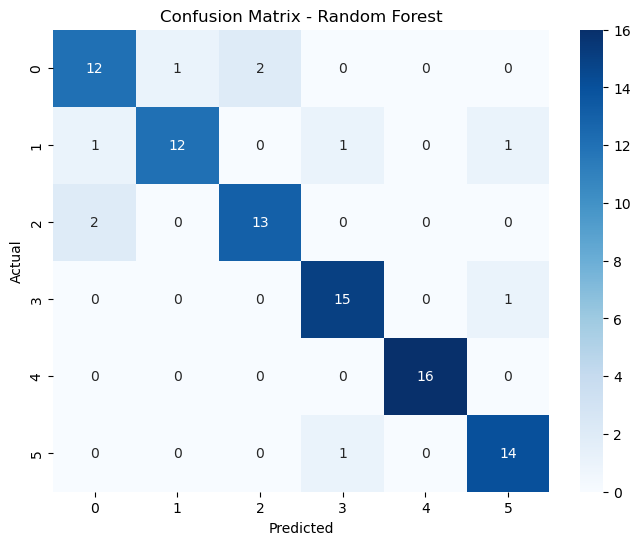

In [34]:
# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('rf_confusion_matrix.png')
plt.show()


Feature Importance:
  Feature  Importance
2      Mg    0.190209
5       K    0.139386
1      Na    0.135271
3      Al    0.116617
6      Ca    0.114928
0      RI    0.114787
7      Ba    0.093062
4      Si    0.070679
8      Fe    0.025061


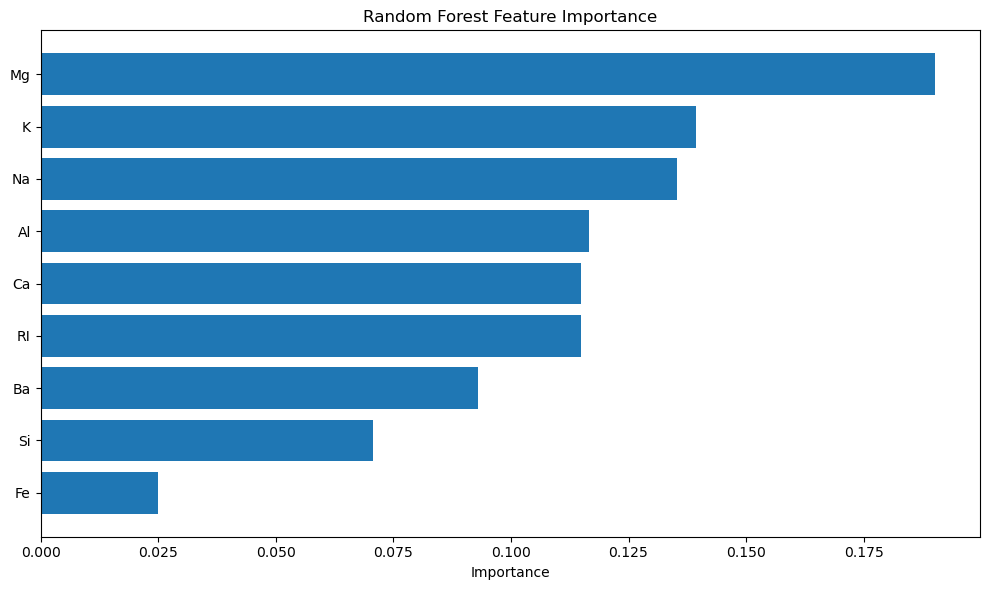

In [35]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('rf_feature_importance.png')
plt.show()

In [36]:
# TASK 5: BAGGING AND BOOSTING METHODS

In [37]:
# 5.1 Bagging Classifier
print("\n5.1 Bagging Classifier:")
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=10),
    n_estimators=50,
    random_state=42
)
bagging_model.fit(X_train, y_train)
y_pred_bag = bagging_model.predict(X_test)

print(f"Bagging Accuracy: {accuracy_score(y_test, y_pred_bag):.4f}")
print(f"Bagging F1-Score (macro): {f1_score(y_test, y_pred_bag, average='macro'):.4f}")

# 5.2 Gradient Boosting
print("\n5.2 Gradient Boosting Classifier:")
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

print(f"Gradient Boosting Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"Gradient Boosting F1-Score (macro): {f1_score(y_test, y_pred_gb, average='macro'):.4f}")



5.1 Bagging Classifier:
Bagging Accuracy: 0.8478
Bagging F1-Score (macro): 0.8444

5.2 Gradient Boosting Classifier:
Gradient Boosting Accuracy: 0.8913
Gradient Boosting F1-Score (macro): 0.8882


In [38]:
# Comparison Table
print("\n" + "-"*50)
print("MODEL COMPARISON")
print("-"*50)
print(f"{'Model':<20} {'Accuracy':<12} {'F1-Score (macro)':<18}")
print("-"*50)
print(f"{'Random Forest':<20} {accuracy_score(y_test, y_pred_rf):.4f}         {f1_score(y_test, y_pred_rf, average='macro'):.4f}")
print(f"{'Bagging':<20} {accuracy_score(y_test, y_pred_bag):.4f}         {f1_score(y_test, y_pred_bag, average='macro'):.4f}")
print(f"{'Gradient Boosting':<20} {accuracy_score(y_test, y_pred_gb):.4f}         {f1_score(y_test, y_pred_gb, average='macro'):.4f}")



--------------------------------------------------
MODEL COMPARISON
--------------------------------------------------
Model                Accuracy     F1-Score (macro)  
--------------------------------------------------
Random Forest        0.8913         0.8894
Bagging              0.8478         0.8444
Gradient Boosting    0.8913         0.8882


In [39]:
# Cross-validation scores
print("\nCross-Validation Scores (5-fold):")
cv_rf = cross_val_score(rf_model, X_resampled, y_resampled, cv=5)
cv_bag = cross_val_score(bagging_model, X_resampled, y_resampled, cv=5)
cv_gb = cross_val_score(gb_model, X_resampled, y_resampled, cv=5)

print(f"Random Forest CV: {cv_rf.mean():.4f} (+/- {cv_rf.std()*2:.4f})")
print(f"Bagging CV: {cv_bag.mean():.4f} (+/- {cv_bag.std()*2:.4f})")
print(f"Gradient Boosting CV: {cv_gb.mean():.4f} (+/- {cv_gb.std()*2:.4f})")



Cross-Validation Scores (5-fold):
Random Forest CV: 0.8618 (+/- 0.0731)
Bagging CV: 0.8355 (+/- 0.0746)
Gradient Boosting CV: 0.8684 (+/- 0.0278)


In [40]:
# ADDITIONAL NOTES 

print("\n1. EXPLANATION OF BAGGING AND BOOSTING:")

print("BAGGING (Bootstrap Aggregating):")
print("  - Trains multiple models independently on random samples of data")
print("  - Models run in parallel")
print("  - Final prediction = average/vote of all models")
print("  - Reduces variance, prevents overfitting")
print("  - Examples: Random Forest")
print()
print("BOOSTING:")
print("  - Trains models sequentially")
print("  - Each model tries to correct errors of previous model")
print("  - Models run in series")
print("  - Reduces bias, improves accuracy")
print("  - Examples: AdaBoost, Gradient Boosting, XGBoost")
print()
print("KEY DIFFERENCES:")
print("  - Bagging = parallel, Boosting = sequential")
print("  - Bagging reduces variance, Boosting reduces bias")
print("  - Bagging less prone to overfitting than Boosting")
print("  - Boosting generally gives higher accuracy but may overfit")

print("\n2. HANDLING IMBALANCED DATA:")

print("Methods to handle imbalance:")
print("  a) RESAMPLING TECHNIQUES:")
print("     - Oversampling (SMOTE): Create synthetic samples of minority class")
print("     - Undersampling: Reduce majority class samples")
print("     - Combination (SMOTE + Tomek links)")
print()
print("  b) ALGORITHM-BASED METHODS:")
print("     - Class weights: Assign higher weight to minority class")
print("     - Balanced Random Forest")
print("     - EasyEnsemble")
print()
print("  c) EVALUATION METRICS FOR IMBALANCED DATA:")
print("     - Use Precision, Recall, F1-Score instead of Accuracy")
print("     - Use ROC-AUC")
print("     - Use Confusion Matrix")
print()
print("  d) In this project: Used SMOTE to balance classes")
print("     - Created synthetic samples for minority classes")
print("     - Improved model's ability to detect rare glass types")




1. EXPLANATION OF BAGGING AND BOOSTING:
BAGGING (Bootstrap Aggregating):
  - Trains multiple models independently on random samples of data
  - Models run in parallel
  - Final prediction = average/vote of all models
  - Reduces variance, prevents overfitting
  - Examples: Random Forest

BOOSTING:
  - Trains models sequentially
  - Each model tries to correct errors of previous model
  - Models run in series
  - Reduces bias, improves accuracy
  - Examples: AdaBoost, Gradient Boosting, XGBoost

KEY DIFFERENCES:
  - Bagging = parallel, Boosting = sequential
  - Bagging reduces variance, Boosting reduces bias
  - Bagging less prone to overfitting than Boosting
  - Boosting generally gives higher accuracy but may overfit

2. HANDLING IMBALANCED DATA:
Methods to handle imbalance:
  a) RESAMPLING TECHNIQUES:
     - Oversampling (SMOTE): Create synthetic samples of minority class
     - Undersampling: Reduce majority class samples
     - Combination (SMOTE + Tomek links)

  b) ALGORITHM-BAS